In [9]:
# TODO: write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [10]:
# TODO: write your code here
df=pd.read_csv('CAR_DETAILS.csv',index_col=0)
df.head()


,year,selling_price,km_driven,fuel,seller_type,transmission,owner
name,,,,,,,
Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [11]:
df.shape

(4340, 7)

In [12]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4340 entries, Maruti 800 AC to Renault KWID RXT
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year           4340 non-null   int64 
 1   selling_price  4340 non-null   int64 
 2   km_driven      4340 non-null   int64 
 3   fuel           4340 non-null   object
 4   seller_type    4340 non-null   object
 5   transmission   4340 non-null   object
 6   owner          4340 non-null   object
dtypes: int64(3), object(4)
memory usage: 271.2+ KB


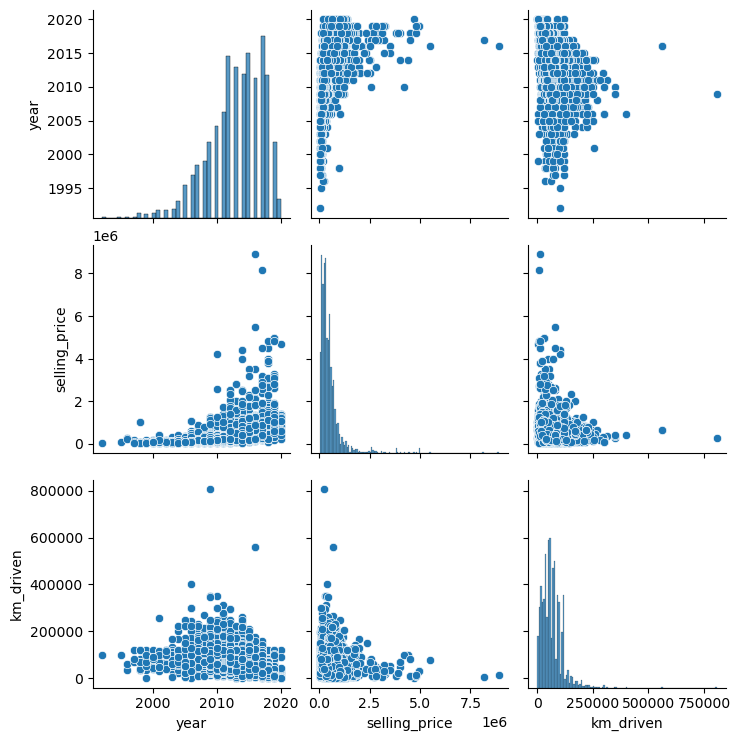

In [14]:
# TODO: write your code here
sns.pairplot(df)
plt.show()

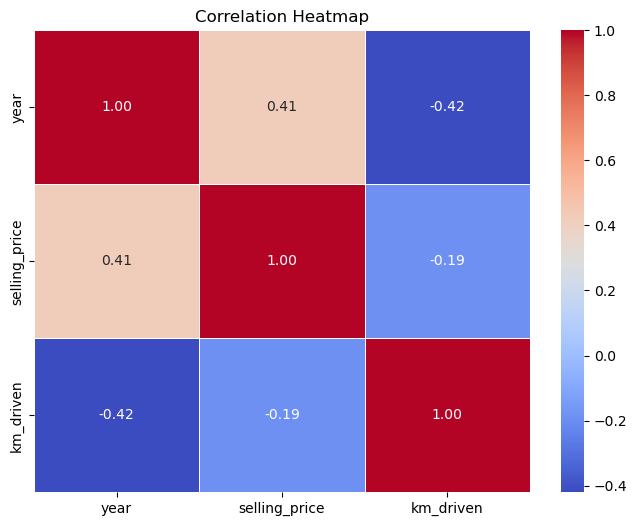

In [15]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True) 
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


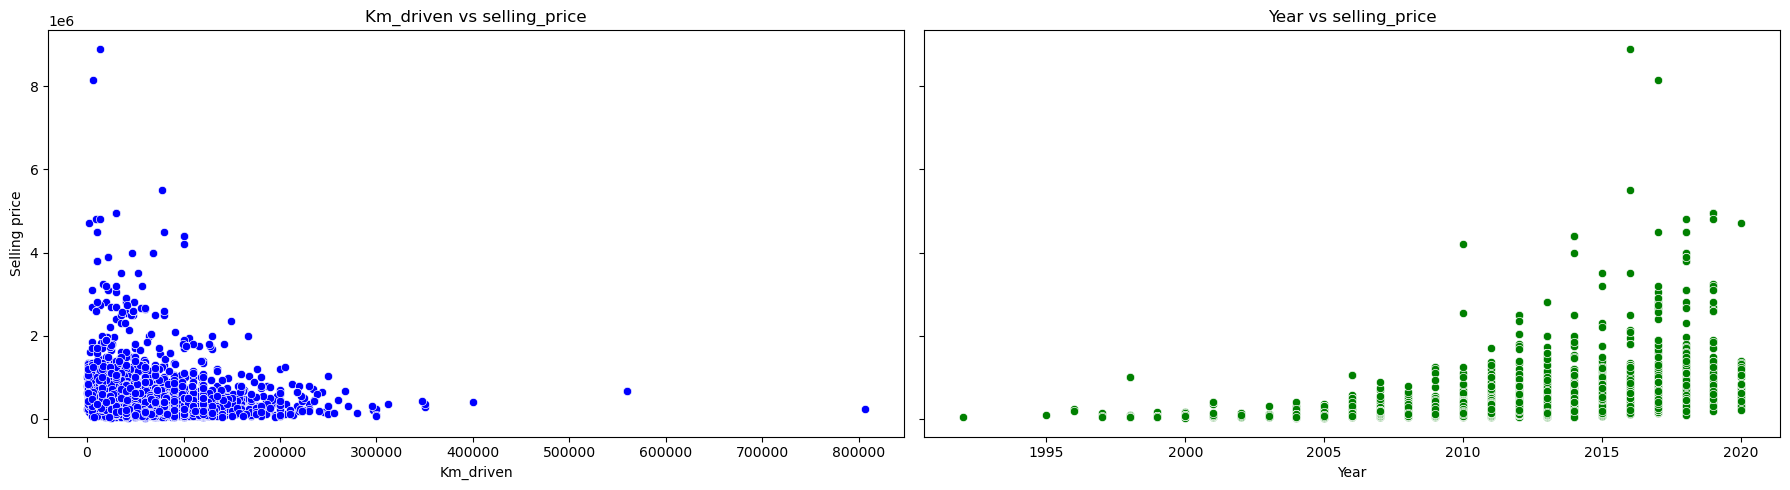

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)


sns.scatterplot(data=df, x="km_driven", y="selling_price", ax=axes[0], color="blue")
axes[0].set_title("Km_driven vs selling_price")
axes[0].set_xlabel("Km_driven")
axes[0].set_ylabel("Selling price")


sns.scatterplot(data=df, x="year", y="selling_price", ax=axes[1], color="green")
axes[1].set_title("Year vs selling_price")
axes[1].set_xlabel("Year")




plt.tight_layout()
plt.show()

In [19]:
# TODO: write your code here

X = df[["km_driven", "year"]].values
y = df["selling_price"].values


print(f"X shape (Features): {X.shape}")
print(f"y shape (Target): {y.shape}")


X shape (Features): (4340, 2)
y shape (Target): (4340,)


In [20]:
# TODO: write your code here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (3472, 2)
X_test shape:  (868, 2)
y_train shape: (3472,)
y_test shape:  (868,)


In [21]:
# TODO: write your code here
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)


X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Verification - Training Scaled Means (should be close to 0):", np.round(X_train_scaled.mean(axis=0), 2))
print("Verification - Training Scaled Stds (should be exactly 1): ", np.round(X_train_scaled.std(axis=0), 2))

Verification - Training Scaled Means (should be close to 0): [-0. -0.]
Verification - Training Scaled Stds (should be exactly 1):  [1. 1.]


In [23]:
# TODO: write your code here

def train_gradient_descent(X, y, learning_rate, epochs):
   
    n_samples, n_features = X.shape

   
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

 
    for epoch in range(epochs):
        
        y_pred = X.dot(w) + b

       
        error = y_pred - y

        
        mse = np.mean(error**2)
        cost_history.append(mse)

       
        dw = (2 / n_samples) * X.T.dot(error)
        db = (2 / n_samples) * np.sum(error)

       
        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b, cost_history



weights, intercept, cost_history = train_gradient_descent(
    X_train_scaled, y_train, learning_rate=0.05, epochs=1000
)

print("--- Final Model Parameters ---")
print(f"Intercept (b): {intercept:.4f}")
print(f"Weights (w):   {np.round(weights, 4)}")
print(f"               [km_driven: {weights[0]:.4f}, year: {weights[1]:.4f}]")


--- Final Model Parameters ---
Intercept (b): 507767.4683
Weights (w):   [-14878.1531 237270.4999]
               [km_driven: -14878.1531, year: 237270.4999]


--- Baseline Model Results ---
Final Weights (w):   [-14878.8526 237269.8005]
               [km_driven: -14878.1531, year: 237270.4999]
Final Intercept (b): 507767.4675
Final Cost (MSE):    282566785809.4753



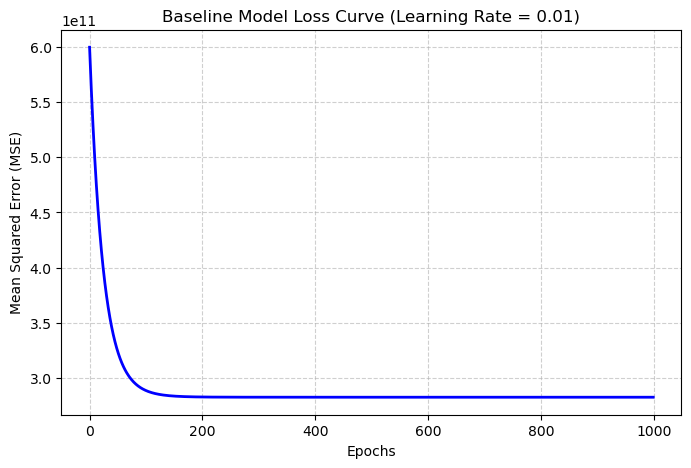

In [25]:
# TODO: write your code here
learning_rate = 0.01
epochs = 1000

w_baseline, b_baseline, cost_history_baseline = train_gradient_descent(
    X_train_scaled, y_train, learning_rate=learning_rate, epochs=epochs
)

print("--- Baseline Model Results ---")
print(f"Final Weights (w):   {np.round(w_baseline, 4)}")
print(f"               [km_driven: {weights[0]:.4f}, year: {weights[1]:.4f}]")
print(f"Final Intercept (b): {b_baseline:.4f}")
print(f"Final Cost (MSE):    {cost_history_baseline[-1]:.4f}\n")


plt.figure(figsize=(8, 5))
plt.plot(cost_history_baseline, color="blue", linewidth=2)
plt.title("Baseline Model Loss Curve (Learning Rate = 0.01)")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [26]:
# TODO: write your code here

w_original = w_baseline / X_std
b_original = b_baseline - np.sum((w_baseline * X_mean) / X_std)


print("--- Unscaled (Original Space) Model Parameters ---")
print(f"Original Intercept (b_orig): {b_original:.4f}")
print(f"Original Weights (w_orig):   {np.round(w_original, 4)}")
print(f"                             [km_driven: {w_original[0]:.4f}, year: {w_original[1]:.4f}]")


--- Unscaled (Original Space) Model Parameters ---
Original Intercept (b_orig): -113060349.4694
Original Weights (w_orig):   [-3.17300000e-01  5.64244721e+04]
                             [km_driven: -0.3173, year: 56424.4721]


c:\Users\jeeva\anaconda3\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_20532\3994382725.py:21: RuntimeWarning: overflow encountered in square
  mse = np.mean(error**2)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_20532\1471228419.py:16: RuntimeWarning: overflow encountered in square
  test_mse = np.mean((y_test_pred - y_test) ** 2)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_20532\3994382725.py:25: RuntimeWarning: overflow encountered in dot
  dw = (2 / n_samples) * X.T.dot(error)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_20532\3994382725.py:15: RuntimeWarning: invalid value encountered in dot
  y_pred = X.dot(w) + b
c:\Users\jeeva\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


OPTIMAL HYPERPARAMETERS FOUND
Best Learning Rate: 0.01
Best Epochs:        500
Lowest Test MSE:    255703508226.6118



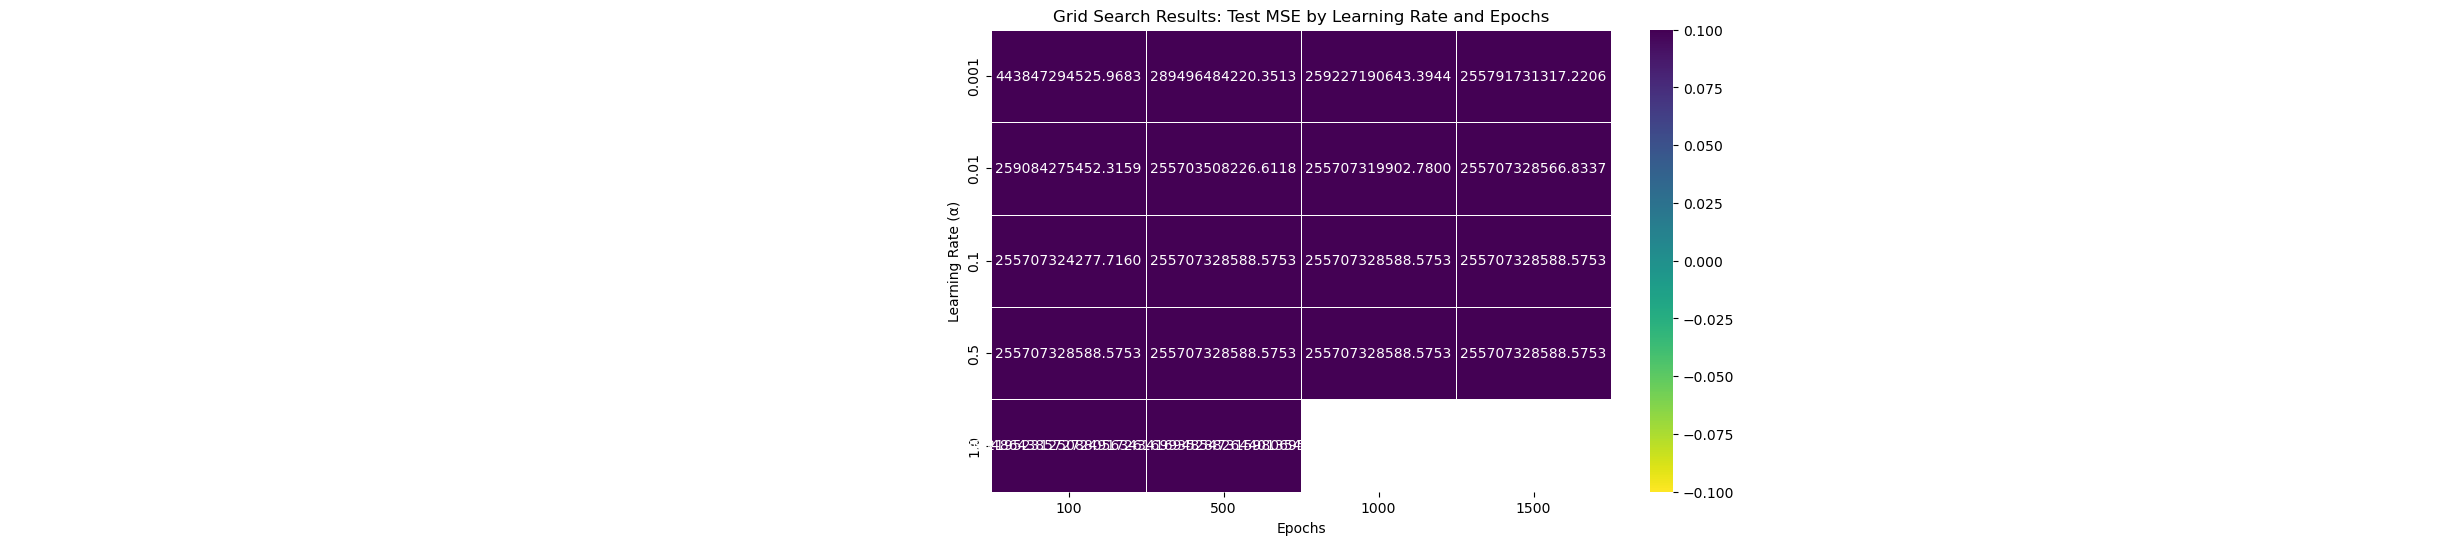

In [29]:
# TODO: write your code he
results = []
learning_rate=[0.001,0.01,0.1,0.5,1.0]
epoch_options=[100,500,1000,1500]
for lr in learning_rates:
    for epochs in epoch_options:
     
        w, b, _ = train_gradient_descent(
            X_train_scaled, y_train, learning_rate=lr, epochs=epochs
        )

        # Generate predictions on the scaled test data
        y_test_pred = X_test_scaled.dot(w) + b

        # Compute evaluation metric (Test MSE)
        test_mse = np.mean((y_test_pred - y_test) ** 2)

        # Append configuration and result
        results.append({"Learning Rate": lr, "Epochs": epochs, "Test MSE": test_mse})


df_results = pd.DataFrame(results)
pivot_table = df_results.pivot(
    index="Learning Rate", columns="Epochs", values="Test MSE"
)


best_run = df_results.loc[df_results["Test MSE"].idxmin()]
print("=" * 40)
print("OPTIMAL HYPERPARAMETERS FOUND")
print("=" * 40)
print(f"Best Learning Rate: {best_run['Learning Rate']}")
print(f"Best Epochs:        {int(best_run['Epochs'])}")
print(f"Lowest Test MSE:    {best_run['Test MSE']:.4f}\n")

plt.figure(figsize=(10, 6))
# Using 'viridis_r' so that lower MSE values (better performance) appear darker/more intense
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis_r", linewidths=0.5)
plt.title("Grid Search Results: Test MSE by Learning Rate and Epochs")
plt.ylabel("Learning Rate (α)")
plt.xlabel("Epochs")
plt.show()


Retraining Final Model (LR: 0.01 | Epochs: 500)
Final Weights (w_final):   [-15156.9585 236991.531 ]
Final Intercept (b_final): 507746.6377
Final Training MSE:        282566881100.6187



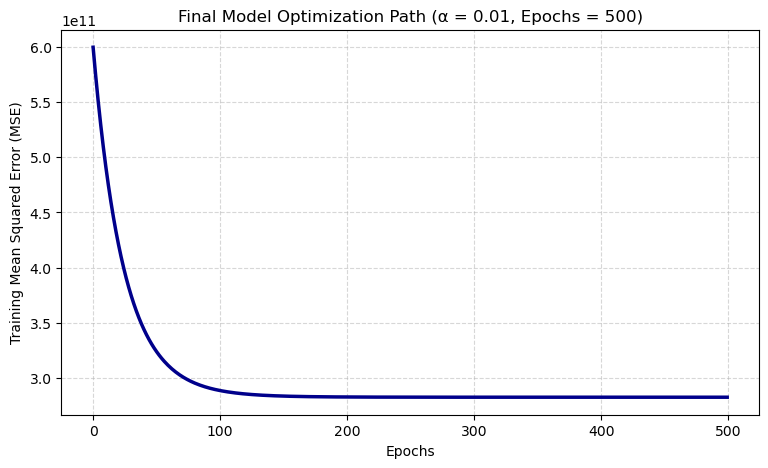

In [30]:
# TODO: write your code here

best_lr = best_run["Learning Rate"]
best_epochs = int(best_run["Epochs"])

print("=" * 50)
print(f"Retraining Final Model (LR: {best_lr} | Epochs: {best_epochs})")
print("=" * 50)

w_final, b_final, cost_history_final = train_gradient_descent(
    X_train_scaled, y_train, learning_rate=best_lr, epochs=best_epochs
)


print(f"Final Weights (w_final):   {np.round(w_final, 4)}")
print(f"Final Intercept (b_final): {b_final:.4f}")
print(f"Final Training MSE:        {cost_history_final[-1]:.4f}\n")


plt.figure(figsize=(9, 5))
plt.plot(cost_history_final, color="darkblue", linewidth=2.5)
plt.title(
    f"Final Model Optimization Path (α = {best_lr}, Epochs = {best_epochs})"
)
plt.xlabel("Epochs")
plt.ylabel("Training Mean Squared Error (MSE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



In [31]:
# TODO: write your code here

y_pred_test = X_test_scaled.dot(w_final) + b_final
mae = np.mean(np.abs(y_pred_test - y_test))
mse = np.mean((y_pred_test - y_test) ** 2)
rmse = np.sqrt(mse)
ss_residual = np.sum((y_test - y_pred_test) ** 2)
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_residual / ss_total)
print("=" * 45)
print("  FROM-SCRATCH MODEL TEST PERFORMANCE REPORT  ")
print("=" * 45)
print(f"Mean Absolute Error (MAE):    {mae:.4f}")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²):         {r2:.4f}")
print("=" * 45)


  FROM-SCRATCH MODEL TEST PERFORMANCE REPORT  
Mean Absolute Error (MAE):    256332.6338
Mean Squared Error (MSE):     255703508226.6118
Root Mean Squared Error (RMSE): 505671.3441
R-squared Score (R²):         0.1621


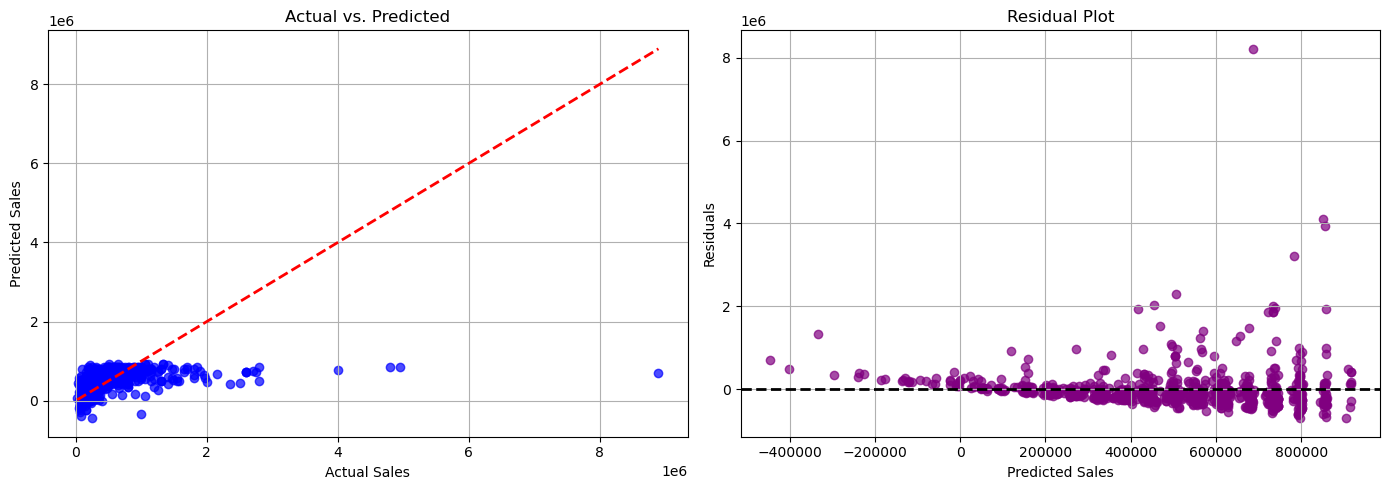

In [32]:
# TODO: write your code here
residuals = y_test - y_pred_test
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
)
plt.title("Actual vs. Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)


plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, residuals, color="purple", alpha=0.7)
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.grid(True)

plt.tight_layout()
plt.show()


In [35]:
# TODO: write your code here
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("=" * 55)
print("             MODEL PARAMETER COMPARISON             ")
print("=" * 55)
print("--- Scikit-Learn Model (Closed-Form) ---")
print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"Weights:   {np.round(lr_model.coef_, 4)}")
print(f"           [km_driven: {lr_model.coef_[0]:.4f}, year: {lr_model.coef_[1]:.4f}]")
print("-" * 55)
print("--- Your Custom Model (Gradient Descent + Unscaled) ---")
print(f"Intercept: {b_original:.4f}")
print(f"Weights:   {np.round(w_original, 4)}")
print(f"           [km_driven: {w_original[0]:.4f}, year: {w_original[1]:.4f}]")
print("=" * 55)

             MODEL PARAMETER COMPARISON             
--- Scikit-Learn Model (Closed-Form) ---
Intercept: -113060685.3116
Weights:   [-3.17200000e-01  5.64246384e+04]
           [km_driven: -0.3172, year: 56424.6384]
-------------------------------------------------------
--- Your Custom Model (Gradient Descent + Unscaled) ---
Intercept: -113060349.4694
Weights:   [-3.17300000e-01  5.64244721e+04]
           [km_driven: -0.3173, year: 56424.4721]


In [36]:
# TODO: write your code here
y_pred_sklearn = lr_model.predict(X_test)

mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
mse_sk = mean_squared_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
r2_sk = r2_score(y_test, y_pred_sklearn)

print("=" * 45)
print("   SCIKIT-LEARN MODEL TEST PERFORMANCE REPORT  ")
print("=" * 45)
print(f"Mean Absolute Error (MAE):    {mae_sk:.4f}")
print(f"Mean Squared Error (MSE):     {mse_sk:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sk:.4f}")
print(f"R-squared Score (R²):         {r2_sk:.4f}")
print("=" * 45)

   SCIKIT-LEARN MODEL TEST PERFORMANCE REPORT  
Mean Absolute Error (MAE):    256362.4856
Mean Squared Error (MSE):     255707328588.5748
Root Mean Squared Error (RMSE): 505675.1216
R-squared Score (R²):         0.1621


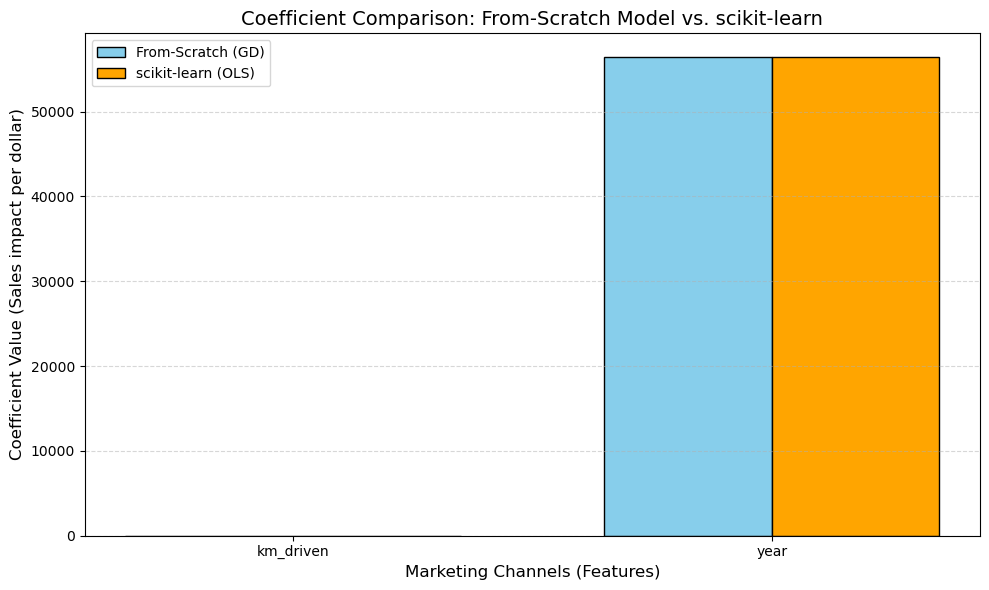

In [39]:
# TODO: write your code here

features = ["km_driven", "year"]
x_indices = np.arange(len(features))
bar_width = 0.35

scratch_coefficients = [w_original[0], w_original[1]]
sklearn_coefficients = [lr_model.coef_[0], lr_model.coef_[1]]

plt.figure(figsize=(10, 6))

plt.bar(
    x_indices - bar_width / 2,
    scratch_coefficients,
    width=bar_width,
    label="From-Scratch (GD)",
    color="skyblue",
    edgecolor="black",
)


plt.bar(
    x_indices + bar_width / 2,
    sklearn_coefficients,
    width=bar_width,
    label="scikit-learn (OLS)",
    color="orange",
    edgecolor="black",
)


plt.title(
    "Coefficient Comparison: From-Scratch Model vs. scikit-learn", fontsize=14
)
plt.xlabel("Marketing Channels (Features)", fontsize=12)
plt.ylabel("Coefficient Value (Sales impact per dollar)", fontsize=12)
plt.xticks(x_indices, features)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


             FINAL METRICS COMPARISON             
          From-Scratch (GD)  scikit-learn (OLS)
Metric                                         
MAE            2.563326e+05        2.563625e+05
MSE            2.557035e+11        2.557073e+11
RMSE           5.056713e+05        5.056751e+05
R² Score       1.621000e-01        1.620800e-01



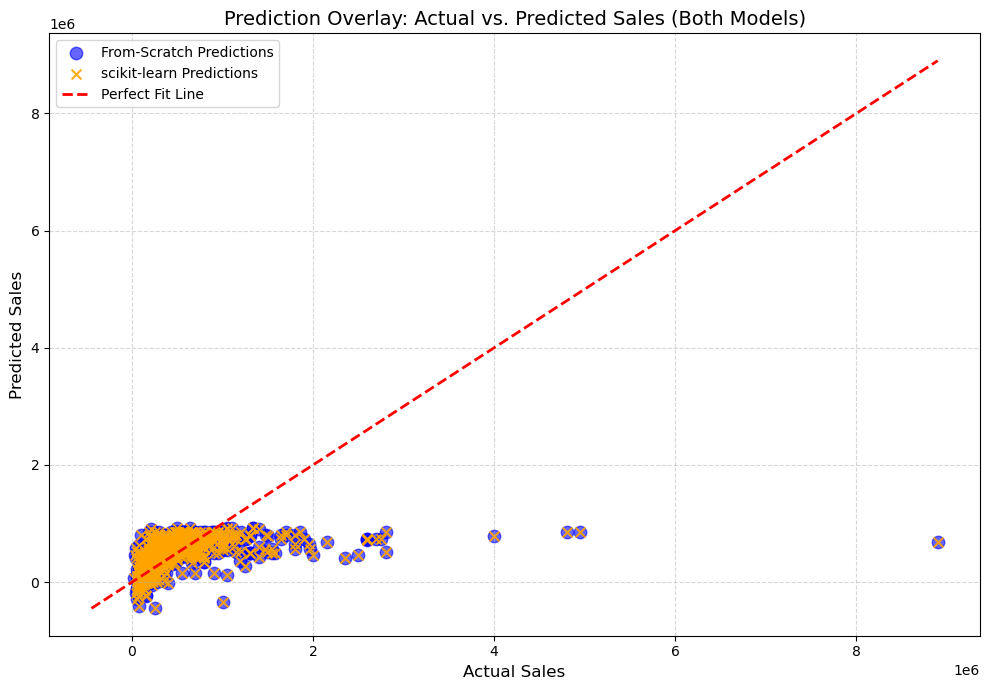

In [40]:
# TODO: write your code here

metrics_data = {
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "From-Scratch (GD)": [mae, mse, rmse, r2],
    "scikit-learn (OLS)": [mae_sk, mse_sk, rmse_sk, r2_sk],
}

df_comparison = pd.DataFrame(metrics_data)

df_comparison.set_index("Metric", inplace=True)

print("=" * 50)
print("             FINAL METRICS COMPARISON             ")
print("=" * 50)
print(df_comparison.round(5))
print("=" * 50 + "\n")


plt.figure(figsize=(10, 7))


plt.scatter(
    y_test,
    y_pred_test,
    color="blue",
    marker="o",
    alpha=0.6,
    s=80,
    label="From-Scratch Predictions",
)


plt.scatter(
    y_test,
    y_pred_sklearn,
    color="orange",
    marker="x",
    alpha=0.9,
    s=50,
    label="scikit-learn Predictions",
)


min_val = min(y_test.min(), y_pred_test.min(), y_pred_sklearn.min())
max_val = max(y_test.max(), y_pred_test.max(), y_pred_sklearn.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit Line",
)


plt.title(
    "Prediction Overlay: Actual vs. Predicted Sales (Both Models)", fontsize=14
)
plt.xlabel("Actual Sales", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
